In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv('amazon_sales_dataset.csv')
df['order_date'] = pd.to_datetime(df['order_date'], errors = 'coerce')
df['semaine'] = df['order_date'].dt.to_period('W')
df['mois'] = df['order_date'].dt.to_period('M')
df['year'] = df['order_date'].dt.to_period('Y')

In [37]:
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,semaine,mois,year
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022-04-11/2022-04-17,2022-04,2022
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023-03-06/2023-03-12,2023-03,2023
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022-09-26/2022-10-02,2022-09,2022
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022-04-11/2022-04-17,2022-04,2022
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022-03-07/2022-03-13,2022-03,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95,2022-08-29/2022-09-04,2022-09,2022
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05,2022-06-27/2022-07-03,2022-07,2022
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92,2023-02-13/2023-02-19,2023-02,2023
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16,2022-09-26/2022-10-02,2022-09,2022


In [40]:
semaine = (
    df
    .groupby('semaine')
    .size()
)
mois = (
    df
    .groupby('mois')
    .size()
)
year = (
    df
    .groupby('year')
    .size()
)


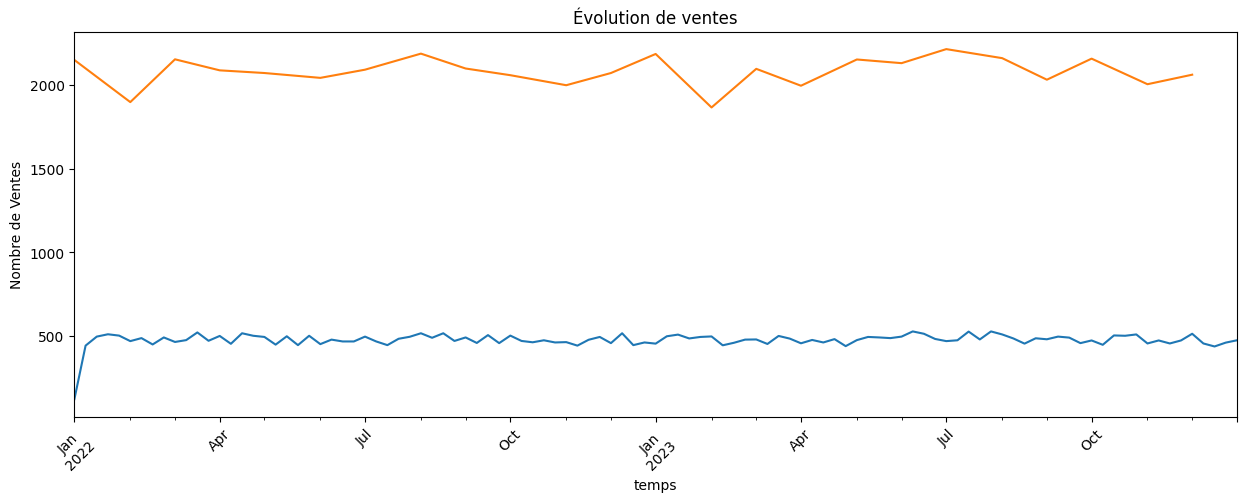

In [49]:
plt.figure(figsize = (15,5))
semaine.plot()
mois.plot()
plt.title('Évolution de ventes')
plt.xlabel('temps')
plt.ylabel('Nombre de Ventes')
plt.xticks(rotation = 45)
plt.show()

In [52]:
year[1] - year[0]

C:\Users\TIMaystar\AppData\Local\Temp\ipykernel_17892\2736024721.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  year[1] - year[0]


np.int64(148)

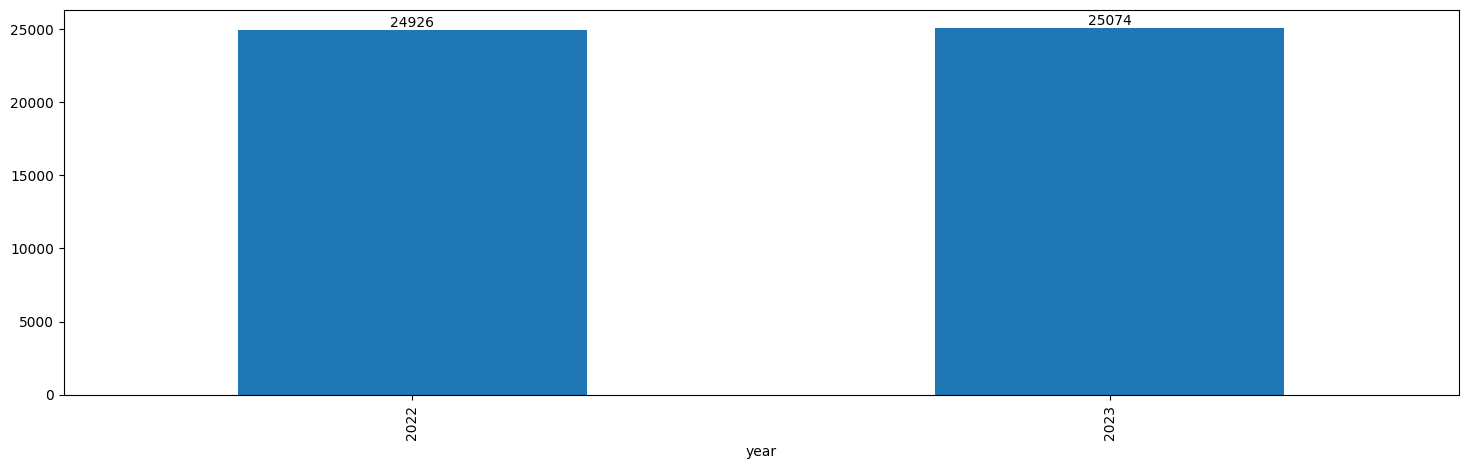

In [46]:
plt.figure(figsize = (18,5))
ax = year.plot(kind = 'bar')

for container in ax.containers:
    ax.bar_label(container)


<Axes: xlabel='year'>

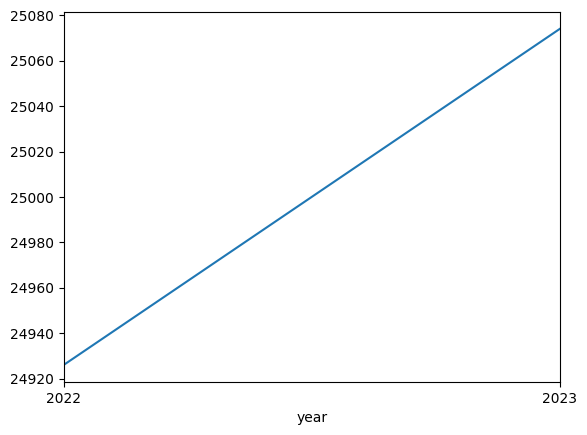

In [47]:
year.plot()

In [50]:
mois.mean()

np.float64(2083.3333333333335)

In [53]:
mois.min()

np.int64(1867)

In [54]:
mois.max()

np.int64(2216)

In [58]:
mois[mois < mois.mean()]

mois
2022-02    1899
2022-05    2073
2022-06    2044
2022-10    2060
2022-11    2000
2022-12    2073
2023-02    1867
2023-04    1997
2023-09    2033
2023-11    2006
2023-12    2063
Freq: M, dtype: int64

In [76]:
jan = df[df['mois'].isin(["2023-01"])]

In [77]:
jan['quantity_sold'].sum()

np.int64(0)

In [64]:
jan

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,semaine,mois,year
14,15,2023-01-08,1051,Beauty,66.65,10,2,North America,Debit Card,4.6,262,59.99,119.98,2023-01-02/2023-01-08,2023-01,2023
23,24,2023-01-21,4108,Beauty,72.05,20,2,Middle East,Debit Card,4.4,129,57.64,115.28,2023-01-16/2023-01-22,2023-01,2023
50,51,2023-01-23,3301,Books,254.57,15,3,Middle East,Cash on Delivery,2.5,361,216.38,649.14,2023-01-23/2023-01-29,2023-01,2023
59,60,2023-01-02,4611,Electronics,388.49,20,5,North America,Wallet,1.3,220,310.79,1553.95,2023-01-02/2023-01-08,2023-01,2023
67,68,2023-01-23,3558,Electronics,74.39,15,3,Middle East,Credit Card,5.0,384,63.23,189.69,2023-01-23/2023-01-29,2023-01,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49886,49887,2023-01-20,3990,Books,454.22,20,2,North America,Credit Card,3.8,434,363.38,726.76,2023-01-16/2023-01-22,2023-01,2023
49887,49888,2023-01-14,3665,Fashion,482.71,5,1,Middle East,Cash on Delivery,4.9,264,458.57,458.57,2023-01-09/2023-01-15,2023-01,2023
49973,49974,2023-01-25,2611,Fashion,292.35,0,3,Middle East,Cash on Delivery,4.7,270,292.35,877.05,2023-01-23/2023-01-29,2023-01,2023
49980,49981,2023-01-01,3664,Beauty,451.07,20,5,Europe,Debit Card,3.4,72,360.86,1804.30,2022-12-26/2023-01-01,2023-01,2023


In [65]:
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,semaine,mois,year
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022-04-11/2022-04-17,2022-04,2022
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023-03-06/2023-03-12,2023-03,2023
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022-09-26/2022-10-02,2022-09,2022
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022-04-11/2022-04-17,2022-04,2022
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022-03-07/2022-03-13,2022-03,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,2022-09-03,1433,Beauty,26.99,0,5,Middle East,Credit Card,2.4,386,26.99,134.95,2022-08-29/2022-09-04,2022-09,2022
49996,49997,2022-07-03,1428,Beauty,294.23,10,5,Asia,Credit Card,3.1,8,264.81,1324.05,2022-06-27/2022-07-03,2022-07,2022
49997,49998,2023-02-17,4651,Electronics,352.11,30,4,Asia,Debit Card,3.1,104,246.48,985.92,2023-02-13/2023-02-19,2023-02,2023
49998,49999,2022-09-30,4371,Beauty,307.54,5,1,Middle East,UPI,1.8,316,292.16,292.16,2022-09-26/2022-10-02,2022-09,2022


In [91]:
s_1 = df[df['mois'].astype(str).isin(["2022-01","2022-02","2022-03"])]
s_2 = df[df['mois'].astype(str).isin(["2022-04","2022-05","2022-06"])]
s_3 = df[df['mois'].astype(str).isin(["2022-07","2022-08","2022-09"])]
s_4 = df[df['mois'].astype(str).isin(["2022-10","2022-11","2022-12"])]
s_5 = df[df['mois'].astype(str).isin(["2023-01","2023-02","2023-03"])]
s_6 = df[df['mois'].astype(str).isin(["2023-04","2023-05","2023-06"])]
s_7 = df[df['mois'].astype(str).isin(["2023-07","2023-08","2023-09"])]
s_8 = df[df['mois'].astype(str).isin(["2023-10","2023-11","2023-12"])]

In [104]:
s_22_1 = (
    s_1
    .groupby('mois')
    .size()
    .sum()
)
s_22_2 = (
    s_2
    .groupby('mois')
    .size()
    .sum()
)
s_22_3 = (
    s_3
    .groupby('mois')
    .size()
    .sum()
)
s_22_4 = (
    s_4
    .groupby('mois')
    .size()
    .sum()
)
s_23_1 = (
    s_5
    .groupby('mois')
    .size()
    .sum()
)
s_23_2 = (
    s_6
    .groupby('mois')
    .size()
    .sum()
)
s_23_3 = (
    s_7
    .groupby('mois')
    .size()
    .sum()
)
s_23_4 = (
    s_8
    .groupby('mois')
    .size()
    .sum()
)

In [119]:
s_an = pd.Series([s_22_1, s_22_2, s_22_3, s_22_4, s_23_1, s_23_2, s_23_3, s_23_4])

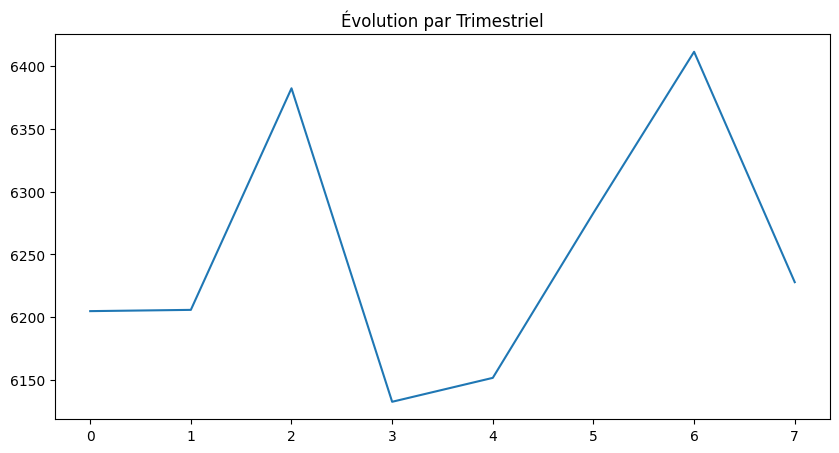

In [124]:
plt.figure(figsize = (10,5))
s_an.plot()
plt.title('Évolution par Trimestriel')
plt.show()

In [103]:
s_22_1

np.int64(6205)

In [107]:
s_an

0    6205
dtype: int64